# Computational Social Science Project #3 

**Enter your Name:** Gisselle Rodriguez Benitez

*Semester:* Fall 2025

## 1. Introduction

### Load data 

In [ ]:
#
# load libraries
# -----------
import pandas as pd
import numpy as np
pd.set_option('display.max_columns', None)
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.preprocessing import LabelBinarizer

from sklearn.preprocessing import LabelEncoder


from sklearn.ensemble import RandomForestClassifier



!pip install xgboost  -q
from xgboost import XGBClassifier as xgb
from sklearn.model_selection import (
    StratifiedKFold,
    train_test_split,
    RandomizedSearchCV,
    cross_val_score
)

!pip install bartpy


from sklearn.metrics import (
    classification_report,
    recall_score, 
    f1_score, 
    make_scorer
)


# There are a few warnings that will appear that will not affect your analysis. Run this code to ignore. 
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

!pip install ISLP -q
from ISLP.bart import BART

# ran in cmd
#!set SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL=True && pip install bartpy -q

In [2]:
#
# read in "Inspections Data 2011-2013" csv data
# -----------
chicago_inspections_2011_to_2013 = pd.read_csv("data/Chicago Inspections 2011-2013.csv", 
                                              low_memory=False)

#
# read in  "Inspections Data 2014_updated" csv data
# -----------
chicago_inspections_2014 = pd.read_csv("data/Chicago Inspections 2014_updated.csv",  # be sure to use the "updated" data here
                                      low_memory=False)

In [3]:
# look at the inspections data
chicago_inspections_2011_to_2013.head()

,Inspection_ID,Inspection_Date,DBA_Name,AKA_Name,License,Facility_Type,Risk,Address,City,State,Zip,Inspection_Type,Results,Latitude,Longitude,Location,Facility_Type_Clean,criticalCount,seriousCount,minorCount,pass_flag,fail_flag,pastFail,pastCritical,pastSerious,pastMinor,timeSinceLast,firstRecord,ID,LICENSE_ID,ACCOUNT_NUMBER,LEGAL_NAME,DOING_BUSINESS_AS_NAME,ADDRESS,CITY,STATE,ZIP_CODE,WARD,PRECINCT,WARD_PRECINCT,POLICE_DISTRICT,LICENSE_CODE,LICENSE_DESCRIPTION,BUSINESS_ACTIVITY_ID,BUSINESS_ACTIVITY,LICENSE_NUMBER,APPLICATION_TYPE,LICENSE_TERM_START_DATE,LICENSE_TERM_EXPIRATION_DATE,LICENSE_STATUS,LATITUDE,LONGITUDE,minDate,maxDate,ageAtInspection,consumption_on_premises_incidental_activity,tobacco,package_goods,outdoor_patio,public_place_of_amusement,limited_business_license,childrens_services_facility_license,tavern,regulated_business_license,filling_station,caterers_liquor_license,mobile_food_license,precipIntensity,temperatureMax,windSpeed,humidity,heat_burglary,heat_garbage,heat_sanitation,criticalFound
0,269961,2013-01-31,SEVEN STAR,SEVEN STAR,30790,Grocery Store,Risk 3 (Low),3352 N BROADWAY,CHICAGO,IL,60657.0,Canvass,Pass,41.943359,-87.644999,"(41.943359344775146, -87.64499875300952)",Other,0,0,2,1,0,0,0,0,0,2.0,1,30790-20110416,2081412.0,63759.0,VIRGINIA DELA ROSA,SEVEN STAR,3352 N BROADWAY 1,CHICAGO,IL,60657.0,44.0,33.0,44-33,19.0,1006.0,Retail Food Establishment,775,Retail Sales of Perishable Foods,30790.0,RENEW,2011-04-16,2013-04-15,AAI,41.943359,-87.644999,2002-02-16,2015-04-15,10.964384,0,1,0,0,0,1,0,0,0,0,0,0,0.014587,53.496667,13.340000,0.900000,26.992376,12.768572,37.748787,0
1,507211,2011-10-18,PANERA BREAD,PANERA BREAD,1475890,Restaurant,Risk 1 (High),6059 N LINCOLN AVE,CHICAGO,IL,60659.0,Canvass,Pass,41.991919,-87.709631,"(41.99191947239194, -87.70963133440333)",Restaurant,0,0,3,1,0,0,0,0,0,2.0,1,1475890-20110416,2081695.0,207283.0,"PANERA, LLC",PANERA BREAD,6059 N LINCOLN AVE C,CHICAGO,IL,60659.0,50.0,23.0,50-23,24.0,1006.0,Retail Food Establishment,775,Retail Sales of Perishable Foods,1475890.0,RENEW,2011-04-16,2013-04-15,AAI,41.991919,-87.709631,2004-05-05,2019-04-15,7.457534,0,0,0,0,0,0,0,0,0,0,0,0,0.001907,59.046667,13.016667,0.550000,13.976557,12.895485,15.412267,0
2,507212,2011-10-18,LITTLE QUIAPO RESTAURANT,LITTLE QUIAPO RESTAURANT,1740130,Restaurant,Risk 1 (High),6259 N MCCORMICK RD,CHICAGO,IL,60659.0,Canvass,Fail,41.995632,-87.712707,"(41.99563177556418, -87.71270678169132)",Restaurant,0,2,6,0,1,0,0,0,0,2.0,1,1740130-20110216,2070145.0,3107.0,ENELITA GARCIA,LITTLE QUIAPO RESTAURANT,6259 N MCCORMICK RD,CHICAGO,IL,60659.0,50.0,25.0,50-25,17.0,1006.0,Retail Food Establishment,775,Retail Sales of Perishable Foods,1740130.0,RENEW,2011-02-16,2013-02-15,AAI,41.995632,-87.712707,2007-03-22,2017-02-15,4.578082,0,0,0,0,0,0,0,0,0,0,0,0,0.001907,59.046667,13.016667,0.550000,12.611239,8.004220,8.320330,0
3,507216,2011-10-19,SERGIO'S TAQUERIA PIZZA INC.,SERGIO'S TAQUERIA PIZZA,1447363,Restaurant,Risk 1 (High),3253 W BRYN MAWR AVE,CHICAGO,IL,60659.0,Canvass,Pass,41.982933,-87.710982,"(41.982933189164974, -87.71098225381141)",Restaurant,0,0,6,1,0,0,0,0,0,2.0,1,1447363-20110216,2071895.0,270993.0,SERGIO'S TAZUERIA PIZZA INC.,SERGIO'S TAQUERIA PIZZA INC.,3253 W BRYN MAWR AVE,CHICAGO,IL,60659.0,39.0,48.0,39-48,17.0,1006.0,Retail Food Establishment,775,Retail Sales of Perishable Foods,1447363.0,RENEW,2011-02-16,2013-02-15,AAI,41.982933,-87.710982,2003-12-31,2019-02-15,7.805479,0,0,0,0,0,0,0,0,0,0,0,0,0.002737,56.153333,10.863333,0.616667,35.906383,26.238645,38.186618,0
4,507219,2011-10-20,TARGET STORE # T-2079,TARGET,1679459,Restaurant,Risk 2 (Medium),2112 W PETERSON AVE,CHICAGO,IL,60659.0,Canvass,Fail,41.990729,-87.682979,"(41.99072921796059, -87.68297945359863)",Restaurant,0,2,6,0,1,0,0,0,0,2.0,1,1679459-20100216,2009972.0,15538.0,TARGET CORPORATION,TARGET STORE # T-2079,2112 W PETERSON AVE,CHICAGO,IL,60659.0,40.0,18.0,40-18,24.0,1006.0,Retail Food Establishment,775,Retail Sales of Perishable Foods,1679459.0,RENEW,

In [62]:
# list column names
print(chicago_inspections_2011_to_2013.columns)

print(chicago_inspections_2014.columns)

# checking if any columns are highly related to 

Index(['Facility_Type', 'Risk', 'Inspection_Type', 'Results',
       'Facility_Type_Clean', 'criticalCount', 'seriousCount', 'minorCount',
       'pastFail', 'pastCritical', 'pastSerious', 'pastMinor', 'timeSinceLast',
       'firstRecord', 'WARD_PRECINCT', 'POLICE_DISTRICT',
       'LICENSE_DESCRIPTION', 'APPLICATION_TYPE', 'ageAtInspection',
       'consumption_on_premises_incidental_activity', 'tobacco',
       'package_goods', 'outdoor_patio', 'public_place_of_amusement',
       'limited_business_license', 'childrens_services_facility_license',
       'tavern', 'regulated_business_license', 'filling_station',
       'caterers_liquor_license', 'mobile_food_license', 'precipIntensity',
       'temperatureMax', 'windSpeed', 'humidity', 'heat_burglary',
       'heat_garbage', 'heat_sanitation', 'criticalFound'],
      dtype='object')
Index(['Inspection_ID', 'Inspection_Date', 'DBA_Name', 'AKA_Name', 'License',
       'Facility_Type', 'Risk', 'Address', 'City', 'State', 'Zip',
       'I

In [5]:
# drop column names related to geography, identification, and pass/fail flags that perfectly predict the outcome
chicago_inspections_2011_to_2013.drop(columns = ['AKA_Name', 
                                                 'License',
                                                 'Address',
                                                 'City',
                                                 'State',
                                                 'Zip',
                                                 'Latitude',
                                                 'Longitude',
                                                 'Location',
                                                 'ID',
                                                 'LICENSE_ID',
                                                 'LICENSE_TERM_START_DATE',
                                                 'LICENSE_TERM_EXPIRATION_DATE',
                                                 'LICENSE_STATUS',
                                                 'ACCOUNT_NUMBER',
                                                 'LEGAL_NAME',
                                                 'DOING_BUSINESS_AS_NAME',
                                                 'ADDRESS',
                                                 'CITY',
                                                 'STATE',
                                                 'ZIP_CODE',
                                                 'WARD',
                                                 'PRECINCT',
                                                 'LICENSE_CODE',
                                                 'BUSINESS_ACTIVITY_ID',
                                                 'BUSINESS_ACTIVITY',
                                                 'LICENSE_NUMBER',
                                                 'LATITUDE',
                                                 'LONGITUDE',
                                                 'pass_flag',
                                                 'fail_flag'],
                                     inplace = True)

# set index
chicago_inspections_2011_to_2013.set_index(['Inspection_ID', 'DBA_Name'], inplace = True)

In [6]:
# convert the inspection date to a datetime format
chicago_inspections_2011_to_2013['Inspection_Date'] = pd.to_datetime(chicago_inspections_2011_to_2013['Inspection_Date'])  

### Visualization

Let's visualize what inspections look like over time.

In [7]:
# First wanted to check if multiple DBA_name has several inspections 

# Count unique inspection dates per DBA_Name
inspection_counts = chicago_inspections_2011_to_2013.groupby('DBA_Name')['Inspection_Date'].nunique()

# Filter DBA_Names with more than one unique inspection date
multiple_inspections = inspection_counts[inspection_counts > 1]

# Number of DBA_Names with multiple inspections
num_multiple_inspections = multiple_inspections.count()

print(f"Number of DBA_Names with multiple inspections over time: {num_multiple_inspections}")

# visualize inspections over time
# -----------
chicago_inspections_2011_to_2013['Inspection_MonthYear'] = chicago_inspections_2011_to_2013['Inspection_Date'].dt.to_period('M')
counts_by_day = chicago_inspections_2011_to_2013.groupby('Inspection_MonthYear').count().rename(columns = {'Facility_Type': 'Count'})['Count'].reset_index()
counts_by_day.set_index(["Inspection_MonthYear"], inplace = True)
counts_by_day.plot(title = "Inspections by Month and Year") 

Number of DBA_Names with multiple inspections over time: 5047


<Axes: title={'center': 'Inspections by Month and Year'}, xlabel='Inspection_MonthYear'>

Let's visualize what the distribution of results looks like.

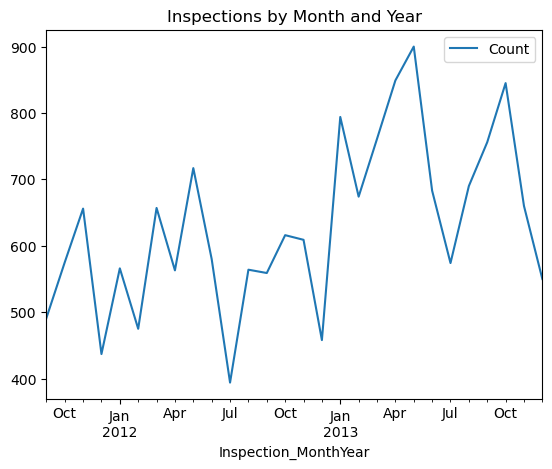

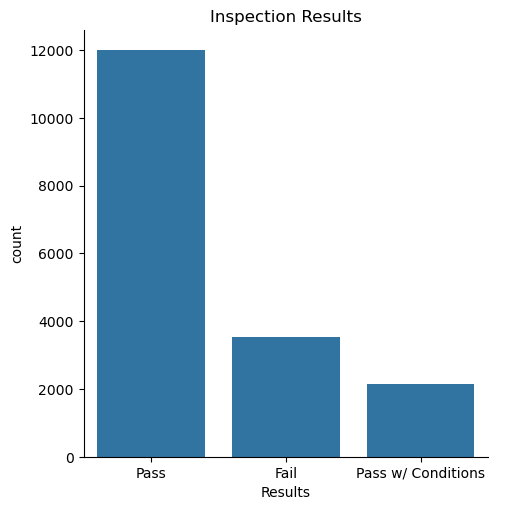

In [8]:
# view inspection results
# -----------
sns.catplot(data = chicago_inspections_2011_to_2013,
           x = "Results",
           kind = "count")

plt.title("Inspection Results")
plt.show()

What if we separate results by facility type?

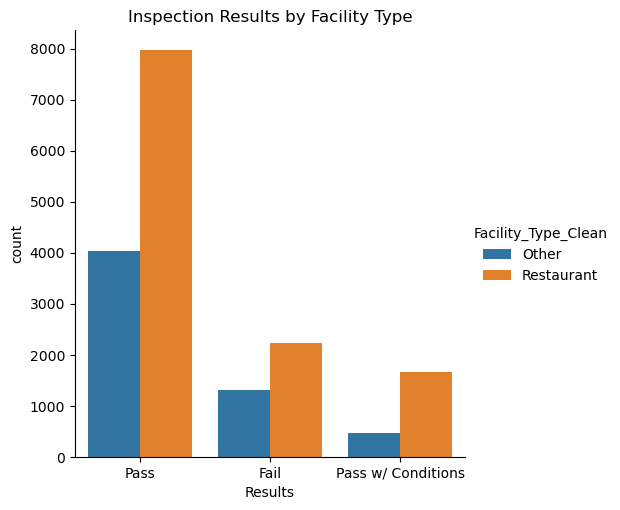

In [9]:
# view inspection results by facility type (restaurant or not)
# -----------
sns.catplot(data = chicago_inspections_2011_to_2013,
            x = "Results",
            kind = "count",
            hue = 'Facility_Type_Clean')

plt.title("Inspection Results by Facility Type")
plt.show();

## 2. Data Preprocessing and Cleaning

In [10]:
# drop datetime info
# -----------
chicago_inspections_2011_to_2013 = chicago_inspections_2011_to_2013.dropna().drop(['Inspection_Date',
                                                                                   'minDate',
                                                                                   'maxDate',
                                                                                   'Inspection_MonthYear'],
                                                                                  axis = 1)



In [11]:
# process target 
# -----------
y = chicago_inspections_2011_to_2013['Results']

# decide if you want to binarize the outcome variable 
# -----------
# Chose to not binarize

mapping = {
    "Pass": 0,
    "Pass w/ Conditions": 1,
    "Fail": 2
}

# If y is a pandas Series
y_encoded = y.map(mapping)

# If y is a numpy array, convert to pandas Series first
# y_encoded = pd.Series(y).map(mapping).values

# process features
# -----------

# create feature dataset
X = chicago_inspections_2011_to_2013.drop(columns = ['Results', 
                                                     'Facility_Type', 
                                                     'LICENSE_DESCRIPTION', 
                                                     'WARD_PRECINCT'])

# converting booleans to ints before dummies
bool_cols = X.select_dtypes(include=['bool']).columns
X[bool_cols] = X[bool_cols].astype(int)


# get dummies
X = pd.get_dummies(X)

In [12]:
# view feature datset

print(X.shape)
X.head()

(15311, 41)


,,criticalCount,seriousCount,minorCount,pastFail,pastCritical,pastSerious,pastMinor,timeSinceLast,firstRecord,POLICE_DISTRICT,ageAtInspection,consumption_on_premises_incidental_activity,tobacco,package_goods,outdoor_patio,public_place_of_amusement,limited_business_license,childrens_services_facility_license,tavern,regulated_business_license,filling_station,caterers_liquor_license,mobile_food_license,precipIntensity,temperatureMax,windSpeed,humidity,heat_burglary,heat_garbage,heat_sanitation,criticalFound,Risk_Risk 1 (High),Risk_Risk 2 (Medium),Risk_Risk 3 (Low),Inspection_Type_Canvass,Facility_Type_Clean_Other,Facility_Type_Clean_Restaurant,APPLICATION_TYPE_C_EXPA,APPLICATION_TYPE_C_LOC,APPLICATION_TYPE_ISSUE,APPLICATION_TYPE_RENEW
Inspection_ID,DBA_Name,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
269961,SEVEN STAR,0,0,2,0,0,0,0,2.0,1,19.0,10.964384,0,1,0,0,0,1,0,0,0,0,0,0,0.014587,53.496667,13.340000,0.900000,26.992376,12.768572,37.748787,0,False,False,True,True,True,False,False,False,False,True
507211,PANERA BREAD,0,0,3,0,0,0,0,2.0,1,24.0,7.457534,0,0,0,0,0,0,0,0,0,0,0,0,0.001907,59.046667,13.016667,0.550000,13.976557,12.895485,15.412267,0,True,False,False,True,False,True,False,False,False,True
507212,LITTLE QUIAPO RESTAURANT,0,2,6,0,0,0,0,2.0,1,17.0,4.578082,0,0,0,0,0,0,0,0,0,0,0,0,0.001907,59.046667,13.016667,0.550000,12.611239,8.004220,8.320330,0,True,False,False,True,False,True,False,False,False,True
507216,SERGIO'S TAQUERIA PIZZA INC.,0,0,6,0,0,0,0,2.0,1,17.0,7.805479,0,0,0,0,0,0,0,0,0,0,0,0,0.002737,56.153333,10.863333,0.616667,35.906383,26.238645,38.186618,0,True,False,False,True,False,True,False,False,False,True
507219,TARGET STORE # T-2079,0,2,6,0,0,0,0,2.0,1,24.0,5.290411,0,0,1,0,0,1,0,0,0,0,0,0,0.009987,52.730000,16.266667,0.690000,9.530785,3.401567,2.126788,0,False,True,False,True,False,True,False,False,False,True


## 3. Fit Models

Now choose 3 different machine learning techniques and apply them below. Choose from one of the algorithms we have used in lab (e.g., logistic regression, random forests, `AdaBoost()`, `xgboost()`, `VotingClassifer()`, or `BART`). 

Detail the basic logic and assumptions underlying each model, its pros/cons, and why it is a plausible choice for this problem. Also, be sure to do the following:

1. Import the appropriate library from sklearn
2. Set up a hyperparameter grid (check out our previous labs to see how to do this)
3. Find the best hyperparameters, and then fit your model (using either train/validation splits or cross-validation)

### Model 1: Random Forrest

**Assumptions**: Random forrest does not rely on strong assumptions about the data. Primarily, it assumes that there is sufficient data in order to identify diverse and unique patterns. Unlike linear models, random forrests do not assume linearity, normality, or homscedasticity. However, random forrests do not handle temporal differences, so predicting future data assumes there is no meaningful temporal relationship. 

**Pros**: Random forest is non-linear and can capture complex relationships better than logistic, for example. Compared to a single tree, for example, it also helps reduce overfittings. Its also not as affected by outiers. It can handle both categorical and numerical data. And less sensitive to changes than logistic regression. 

**Cons**: More difficult to interpret individual variable effects, and this case might be difficult to explain to policymakers or facilities on what determines failure.

**Justification**: Random forrests is a good baseline for classification. I want to be able to compare it to other models that can handle change over time. 

In [13]:
# for cross validation, can use for xgboost too


skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=10
)

# because incorrect passing is likely the most consequential I want to penalize scoring < 2 when should be 2
def class_2_recall(y_true, y_pred):
    return recall_score(y_true, y_pred, labels=[2], average='macro')

class_2_recall_scorer = make_scorer(class_2_recall)

# for validation loop later

def class2_recall_scorer(y_true, y_pred):
    return recall_score(y_true, y_pred, labels=[2], average='macro')

def class2_precision_scorer(y_true, y_pred):
    return precision_score(y_true, y_pred, labels=[2], average='macro')

def class2_f1_scorer(y_true, y_pred):
    return f1_score(y_true, y_pred, labels=[2], average='macro')

scorers = {
    'accuracy': 'accuracy',
    'class2_recall': make_scorer(class2_recall_scorer),
    'class2_precision': make_scorer(class2_precision_scorer),
    'class2_f1': make_scorer(class2_f1_scorer),
}



In [14]:
rf_base = RandomForestClassifier(
    n_estimators = 200,
    class_weight = "balanced",
    random_state = 10)

rf_param_grid = {
    "n_estimators": [200, 400, 800],
    "max_depth": [None, 10, 20, 40],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

rf_tuner = RandomizedSearchCV(
    rf_base,
    rf_param_grid,
    n_iter=20,
    scoring=class_2_recall_scorer,
    cv=skf,
    random_state=10,
    n_jobs=-1
)

rf_tuner.fit(X, y_encoded)

print("\nBest RF parameters:")
print(rf_tuner.best_params_)

print("\nBest RF CV recall-2:", rf_tuner.best_score_)



Best RF parameters:
{'n_estimators': 400, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 40}

Best RF CV recall-2: 0.9293832250213739


In [24]:
rf_best_model = RandomForestClassifier(
    n_estimators = 400,
    min_samples_split = 2,
    min_samples_leaf = 1,
    max_features = "log2",
    max_depth = 40,     
    class_weight = "balanced",
    random_state = 10)

m1_rf = rf_best_model.fit(X, y_encoded)


### Model 2: XGBoost

**Assumptions**: Similar to random forrest, XGBoost makes few assumptions about the functional form of the data, making it useful for non-linear relationships but less informative about whether outcomes are related to time.

**Pros**: The gradient boosting approach sequentially reduces errors, making it better and more flexible. Regularization parameters can also prevent overfitting better than random forrest.

**Cons**: This is likely to take longer, especialy whie hyperparameter tuning. Similar to random forrest, intepretation is also more challenging. 

**Justification**: I want to see whether the sequential/iterative error reduction will allow for better predictions. 

In [16]:
xgb_base = xgb(
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    random_state=10,
    tree_method="hist"
)

xgb_param_grid = {
    "eta": [0.01, 0.05, 0.1],
    "max_depth": [3, 4, 5, 6],
    "min_child_weight": [1, 3, 5],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "n_estimators": [200, 500, 800]
}

xgb_tuner = RandomizedSearchCV(
    xgb_base,
    xgb_param_grid,
    n_iter=20,
    scoring=class_2_recall_scorer,
    cv=skf,
    random_state=10,
    n_jobs=-1
)

xgb_tuner.fit(X, y_encoded)

print("\nBest XGB parameters:")
print(xgb_tuner.best_params_)

print("\nBest XGB CV recall-2:", xgb_tuner.best_score_)


Best XGB parameters:
{'subsample': 0.8, 'n_estimators': 200, 'min_child_weight': 3, 'max_depth': 4, 'eta': 0.01, 'colsample_bytree': 0.8}

Best XGB CV recall-2: 0.9426597011324238


In [17]:
xgb_best_model = xgb(
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    random_state=10,
    tree_method="hist",
    eta= 0.01,
    max_depth= 4,
    min_child_weight= 3,
    subsample= 0.8,
    colsample_bytree= 0.8,
    n_estimators= 200
)

m2_xgb = xgb_best_model.fit(X, y_encoded)

### Model 3: VoteClassifier 

**Assumptions**: The vote classifier assumes that combining the models will imrpve overall performance. 

**Pros**:  The primary benefit of this classifier is that it leverages the strengths of multiple models. And its more likely to be perform better with  imbalanced classes because its combining multiple predictions

**Cons**: Similar to XGBoost, the costs are less interpretability and slower processing. 

**Justification**: Given that failures are rare but important to catch, I think that a model which supports imbalanced class distribution is best. 

In [21]:
from sklearn.ensemble import VotingClassifier

voting_clf = VotingClassifier(
    estimators=[('rf', rf_best_model), ('xgb', xgb_best_model)],
    voting='soft',   # using soft voting to average predicted class probabilities
    weights=[1, 1],  # weighing the same
    n_jobs=-1
)

m3_vc = voting_clf.fit(X, y_encoded)

### Validation Metrics

Be sure to explain which of these metrics you would want to prioritize when conducting predictive auditing in this context and why.

> In this scenario, I assume that false negatives (predicting passing when should be failure) has most public health risk. For this reason, I hypertuned prior to the class2 (failure) recall. The cost of this is that my recall for pass w/ condition is lower, while pass recall is less affected. This also means the city would likely audit more non-fails, but its minimizing the likely of higher risk mistakes. So while this does mean more pass w/ conditions are not correctly identified, it is better that fails are more common (even if incorrect).
> The three have generally the same results, because of my hyperparameter tuning. If I had more time, I would compare with a model that can better account for temporal effects. 

**Hint**: Try writing a for loop to use [`cross_val_score()`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html) to check for accuracy, precision, recall and f1 across all of your models.

In [25]:
models = {
    'Random Forest': m1_rf,
    'XGBoost': m2_xgb,
    'Voting Classifier': m3_vc
}



print("Model Evaluation Metrics with 5-fold CV:\n")

for model_name, model in models.items():
    print(f"{model_name}:")
    for metric_name, scorer in scorers.items():
        scores = cross_val_score(model, 
                                 X, 
                                 y_encoded, 
                                 cv=5, 
                                 scoring=scorer, 
                                 n_jobs=-1)
        print(f"  {metric_name}: Mean={np.mean(scores):.4f} | Std={np.std(scores):.4f}")
    print()

Model Evaluation Metrics with 5-fold CV:

Random Forest:
  accuracy: Mean=0.9209 | Std=0.0096
  class2_recall: Mean=0.9210 | Std=0.0296
  class2_precision: Mean=nan | Std=nan
  class2_f1: Mean=0.8279 | Std=0.0209

XGBoost:
  accuracy: Mean=0.9222 | Std=0.0086
  class2_recall: Mean=0.9446 | Std=0.0227
  class2_precision: Mean=nan | Std=nan
  class2_f1: Mean=0.8338 | Std=0.0176

Voting Classifier:
  accuracy: Mean=0.9225 | Std=0.0094
  class2_recall: Mean=0.9388 | Std=0.0266
  class2_precision: Mean=nan | Std=nan
  class2_f1: Mean=0.8336 | Std=0.0198



In [31]:
from sklearn.model_selection import cross_val_predict

y_pred_rf = cross_val_predict(m1_rf, X, y_encoded, cv=5)
print(classification_report(y_encoded, y_pred_rf, target_names=['Pass', 'Pass w/ cond', 'Fail']))

y_pred_xg = cross_val_predict(m2_xgb, X, y_encoded, cv=5)
print(classification_report(y_encoded, y_pred_xg, target_names=['Pass', 'Pass w/ cond', 'Fail']))

y_pred_vc = cross_val_predict(m3_vc, X, y_encoded, cv=5)
print(classification_report(y_encoded, y_pred_vc, target_names=['Pass', 'Pass w/ cond', 'Fail']))

              precision    recall  f1-score   support

        Pass       0.99      1.00      0.99     10259
Pass w/ cond       0.86      0.52      0.65      1965
        Fail       0.75      0.92      0.83      3087

    accuracy                           0.92     15311
   macro avg       0.87      0.81      0.82     15311
weighted avg       0.93      0.92      0.92     15311

              precision    recall  f1-score   support

        Pass       0.99      1.00      0.99     10259
Pass w/ cond       0.91      0.50      0.65      1965
        Fail       0.75      0.94      0.83      3087

    accuracy                           0.92     15311
   macro avg       0.88      0.81      0.82     15311
weighted avg       0.93      0.92      0.92     15311

              precision    recall  f1-score   support

        Pass       0.99      1.00      0.99     10259
Pass w/ cond       0.90      0.51      0.65      1965
        Fail       0.75      0.94      0.83      3087

    accuracy        

## 4. Policy Simulation

### Interpretable Machine Learning

Use tools like coefficient plots or feature importance plots to investigate your models. Which features contribute to your predictions? Are there any additional features you wish you could incorporate that you don't have available in this analysis?

> The top features that contribute most are the seriousCount, criticalCount,  criticalFound, and minorCount. I am assuming that these are "counts" of unsatisfactory conditions during investigations. This makes sense as these are likely used in a rubric or some other implicit or explicit decision process.
> In terms of additional features, I wish that I could include something about change over time. If these organizations have bettered over time, I'd like the prediction model to account for that change. But neither XGBoost nor Random Forrest account for this unless time-dependent features are provided

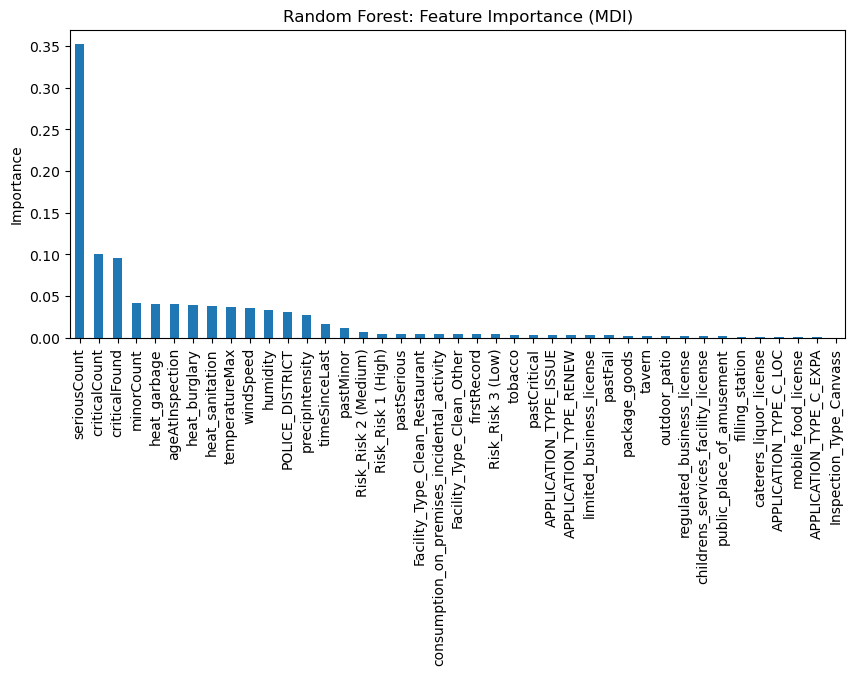

In [32]:
rf_importances = pd.Series(m1_rf.feature_importances_, index=X.columns)
rf_importances.sort_values(ascending=False).plot.bar(figsize=(10,4))
plt.title("Random Forest: Feature Importance (MDI)")
plt.ylabel("Importance")
plt.show()

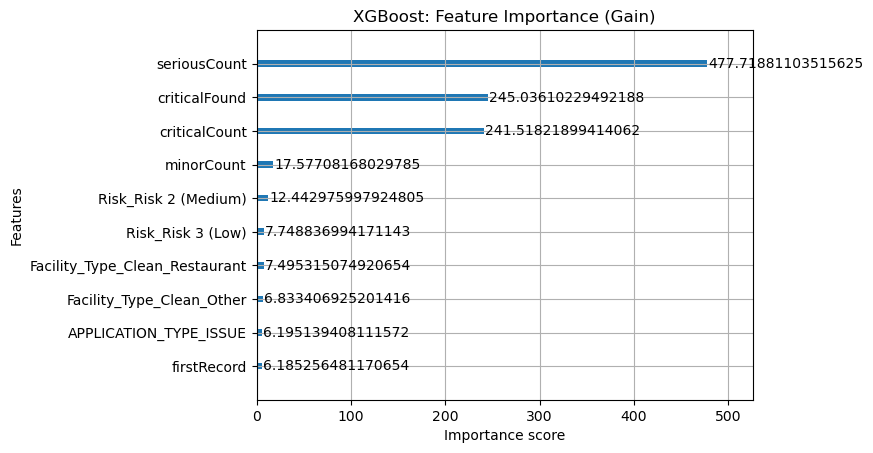

In [35]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

# I used gain here because it provides more detail on the quality of splits, 
# compared to weight which gives us information on how often they are used in splitting

plot_importance(m2_xgb, max_num_features=10, importance_type='gain')
plt.title("XGBoost: Feature Importance (Gain)")
plt.show()

### Prioritize Audits

**Hint**: Look up the [`.predict()`](https://www.kite.com/python/docs/sklearn.linear_model.SGDRegressor.predict), [`.predict_proba()`](https://www.kite.com/python/docs/sklearn.linear_model.LogisticRegression.predict_proba), and [`.sample()`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.sample.html) methods. Then: 
1. Choose one of your models (or train a new simplified model or ensemble!) to predict outcomes and probabilities. 
2. Order your audits by their probability of detecting a "Fail" score
3. Plot your distribution of pass/fail among the first 1,000 observations in the dataset
4. Simulate random audits on the full chicago_2011_to_2013.csv dataset by picking 1,000 observations at random

In [51]:
#
# 1. Choose one of your models (or train a new simplified model or ensemble!) to predict outcomes and probabilities.
# -----------
# using m3_vc

y_pred = voting_clf.predict(X)
probas = voting_clf.predict_proba(X)

cls_index = list(voting_clf.classes_).index(2)  
fail_prob = probas[:, cls_index]
print(voting_clf.classes_)  # Should be [0, 1, 2] 





[0 1 2]
# Predicted 'Fail' among top 1000 (by fail_prob): 241


In [65]:
#
# 2. Order your audits by their probability of detecting a "Fail" score
# -----------
audits = pd.DataFrame(X, columns=X.columns) if not isinstance(X, pd.DataFrame) else X.copy()
audits['fail_prob'] = fail_prob 
audits['y_pred'] = y_pred # predicted class label 
ordered_audits = audits.sort_values('fail_prob', ascending=False).reset_index(drop=True)

top_1000 = ordered_audits.head(1000)

# F most probable class?
most_prob_class = np.argmax(probas, axis=1)
# top 1,000 by 'fail_prob':
top_1000_idx = ordered_audits.iloc[:1000].index
pos_for_top_1000 = ordered_audits.index.get_indexer(top_1000_idx)
top_1000_pred = most_prob_class[pos_for_top_1000]
num_fail = np.sum(top_1000_pred == cls_index)
print(f"# Predicted 'Fail' among top 1000 (by fail_prob): {num_fail}")

print(ordered_audits.head(10)[['fail_prob', 'y_pred']])
print(fail_prob.max(), fail_prob.mean(), fail_prob[:10])

# Predicted 'Fail' among top 1000 (by fail_prob): 241
   fail_prob  y_pred
0   0.906392       2
1   0.904924       2
2   0.904805       2
3   0.902416       2
4   0.901086       2
5   0.901053       2
6   0.900872       2
7   0.900156       2
8   0.899714       2
9   0.899337       2
0.9063920843601228 0.20537423109390823 [0.03835318 0.03205074 0.82269898 0.04279044 0.76262857 0.6680329
 0.03258331 0.0298948  0.03263431 0.03120965]


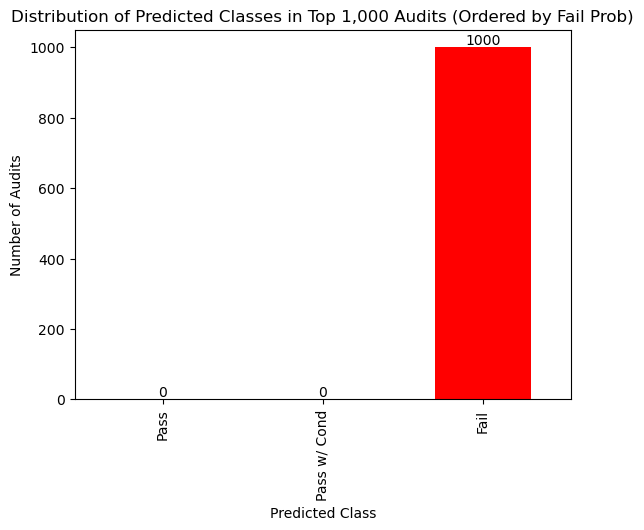

In [66]:
#
# 3. Plot your distribution of pass/fail among the first 1,000 observations in the dataset
# -----------
vc = top_1000['y_pred'].value_counts().reindex([0, 1, 2], fill_value=0)
ax = vc.plot(kind='bar', color=['green', 'gold', 'red'], width=0.6)
for p in ax.patches:
    ax.annotate(str(int(p.get_height())), (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')
plt.title('Distribution of Predicted Classes in Top 1,000 Audits (Ordered by Fail Prob)')
plt.xlabel('Predicted Class')
plt.ylabel('Number of Audits')
plt.xticks(ticks=[0, 1, 2], labels=['Pass', 'Pass w/ Cond', 'Fail'])
plt.show()

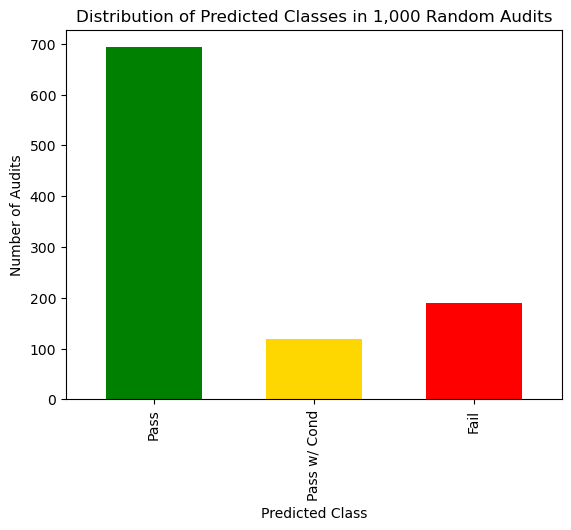

In [60]:
#
# 4. Simulate random audits on the full chicago_2011_to_2013.csv dataset by picking 1,000 observations at random
# -----------

random_1000 = audits.sample(n=1000, random_state=10)
vc_rand = random_1000['y_pred'].value_counts().reindex([0, 1, 2], fill_value=0)
vc_rand.plot(kind='bar', color=['green', 'gold', 'red'], width=0.6)
plt.title('Distribution of Predicted Classes in 1,000 Random Audits')
plt.xlabel('Predicted Class')
plt.ylabel('Number of Audits')
plt.xticks(ticks=[0, 1, 2], labels=['Pass', 'Pass w/ Cond', 'Fail'])
plt.show()


### Predict on 2014 inspection data

Use your favorite model to make predictions based on the features using the "Chicago Inspection 2014_updated.csv" file. Treat this as you would a test dataset. This means you will have to format the features (including removing some features and getting dummies) and the label (binarize and recode) in the same way you did the training data. (Remember the "Results" column is your label). You will then compare your predictions with the actual.

In [64]:
# data processing
# -----------


y_test2014 = chicago_inspections_2014['Results']


mapping = {
    "Pass": 0,
    "Pass w/ Conditions": 1,
    "Fail": 2
}


y_test2014 = y_test2014.map(mapping)


# create feature dataset <- should 
X_test2014 = chicago_inspections_2014.drop(columns = ['Results', 
                                                     'Facility_Type', 
                                                     'LICENSE_DESCRIPTION', 
                                                     'WARD_PRECINCT'])

# converting booleans to ints before dummies
bool_cols = X_test2014.select_dtypes(include=['bool']).columns
X[bool_cols] = X_test2014[bool_cols].astype(int)


# get dummies
X_test2014 = pd.get_dummies(X_test2014)


In [68]:
# predict and compare 

train_feature_names = voting_clf.feature_names_in_

X_test2014 = X_test2014[train_feature_names].copy()

y_pred_2014 = voting_clf.predict(X_test2014)
probas_2014 = voting_clf.predict_proba(X_test2014)

print(classification_report(y_test2014, y_pred_2014, target_names=['Pass', 'Pass w/ cond', 'Fail']))

              precision    recall  f1-score   support

        Pass       1.00      1.00      1.00      3012
Pass w/ cond       0.81      0.49      0.61       712
        Fail       0.69      0.91      0.79       899

    accuracy                           0.90      4623
   macro avg       0.83      0.80      0.80      4623
weighted avg       0.91      0.90      0.90      4623



Like in the training data, the "pass" class is the majority (3012/4623). The model's precision,  recall, and f1-scores are all 1.0, which also drives the weighted average up. 

When the mode predicted "pass w/ conditions" it was correct 81% of the time, but it only found about half of the true "pass w/ condition cases". Given that precision was perfect for "pass", the missed "pass w/ conditions" were likely assigned to "fail" and the incorrect "pass w/ conditions" should have been "fails". 

And finally, only 69% of predicted "fails" were real "fails" (which aligns with the previous comment), but the model catches most actual failures, at 91%. 

## 5. Discussion Questions

1. Why do we need metrics beyond accuracy when using machine learning in the social sciences and public policy?


> In domains that are highly consequential (also including clinical studies, for instance), the types of errors made are important. Some are more dangerous or maybe more expensive. For instance, if the City of Chicago is most concerned with over-auditting institutions that are likely to pass, then prioritizing the recall of failures is not ideal. This also reminds me of the COMPAS analysis, where Black individuals were more likely to be identified as higher risk when not (false positives) relative to white individuals.
>
> Deciding which types of errors to prevent is necessary but complicated, requiring insight into and some ordering of possible consequences. The different metrics allow us to operationalize that ordering. 

2. Imagine that establishments learned about the algorithm being used to determine who gets audited and they started adjusting their behavior (and changing certain key features about themselves that were important for the prediction) to avoid detection. How could policymakers address this interplay between algorithmic decisionmaking and real world behavior?

> The features that drive most of the predictions seem to align closely with what the government aims to prevent: unsafe or unsatisfactory conditions at establishments. The organizations acting on these is unlikely to be an issue. But, some less important features, such as age at inspection or police precinct, could potentially be gamed by moving or transferring ownership. Linking organizations through owners or some other form of identification, for example, may help detect attempts to evade audits.
>
> Beyond this, its important that inspections are frequent or randomized so that the data that feeds the algorithm is accurately reflecting the state of the establishments and the relationship between their details and actual inspection outcomes.